Fetching MNIST data...
Dataset sampled to: X=(70000, 784), y=(70000,)


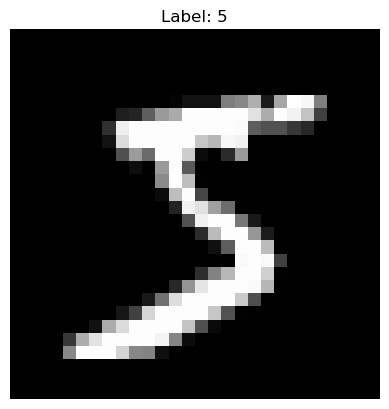

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

print("Fetching MNIST data...")
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

X = X[:70000] / 255.0 
y = y[:70000].astype(np.int64)

print(f"Dataset sampled to: X={X.shape}, y={y.shape}")




plt.imshow(X[0].reshape(28, 28), cmap="gray")
plt.title(f"Label: {y[0]}")
plt.axis("off")
plt.show()

In [15]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC


base_models = [
    ('knn', KNeighborsClassifier(n_neighbors=11)), 
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)), 
    ('log_reg', LogisticRegression(max_iter=2000)), 
    ('dt', DecisionTreeClassifier(max_depth=15, random_state=42)), 
    ('nb', GaussianNB()),
    ('l_svc', LinearSVC(dual=False, random_state=42, max_iter=2000))
]

stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(max_iter=2000), 
    cv=3,
    n_jobs=1 
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Training Stacking Classifier .... ")

stacking_model.fit(X_train, y_train)
print("Training complete!")

Training Stacking Classifier .... 
Training complete!


Stacking Classifier testing Accuracy: 97.72%
Stacking Classifier train Accuracy: 99.90%

Classification Report training:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4845
           1       1.00      1.00      1.00      5513
           2       1.00      1.00      1.00      4857
           3       1.00      1.00      1.00      4965
           4       1.00      1.00      1.00      4888
           5       1.00      1.00      1.00      4398
           6       1.00      1.00      1.00      4788
           7       1.00      1.00      1.00      5045
           8       1.00      1.00      1.00      4833
           9       1.00      1.00      1.00      4868

    accuracy                           1.00     49000
   macro avg       1.00      1.00      1.00     49000
weighted avg       1.00      1.00      1.00     49000


Classification Report testing:
              precision    recall  f1-score   support

           0       0.99      0.99

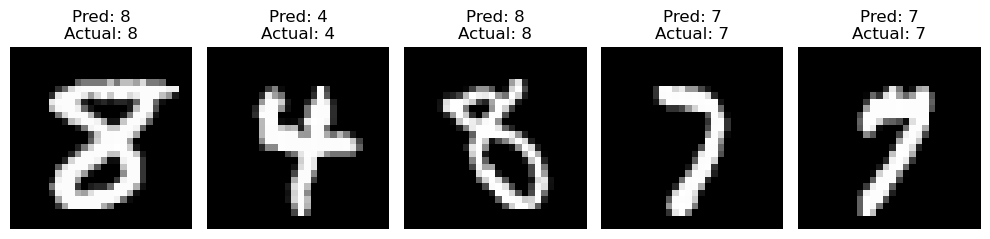

In [16]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_test = stacking_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_test)

print(f"Stacking Classifier testing Accuracy: {accuracy * 100:.2f}%")

y_pred_train = stacking_model.predict(X_train)
accuracy = accuracy_score(y_train, y_pred_train)

print(f"Stacking Classifier train Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report training:")
print(classification_report(y_train, y_pred_train))
print("\nClassification Report testing:")
print(classification_report(y_test, y_pred_test))



plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")
    plt.title(f"Pred: {y_pred_test[i]}\nActual: {y_test[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

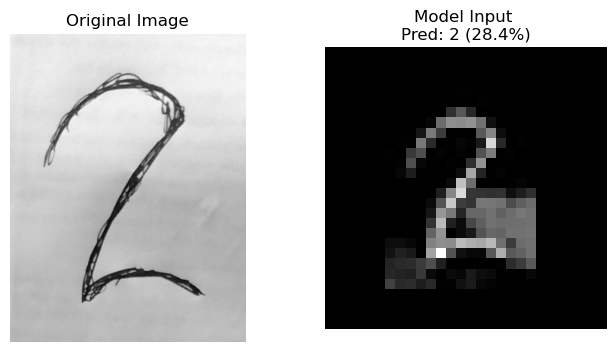

Prediction: 2 | Confidence: 28.45%


In [27]:
from PIL import Image, ImageOps
import os

def predict_custom_image(image_path):
    if not os.path.exists(image_path):
        print(f"File '{image_path}' not found.")
        return

    # conversion to mnist image
    img = Image.open(image_path).convert("L")
    
    #invert if needed
    img_arr = np.array(img)
    if img_arr.mean() > 127:
        img = ImageOps.invert(img)
    
    
    #clean bg
    img = ImageOps.autocontrast(img, cutoff=2)
    img = img.point(lambda p: p if p > 80 else 0) 
    
    img.thumbnail((20, 20), Image.Resampling.LANCZOS)
    final_img = Image.new("L", (28, 28), 0) # Pure black background
    w, h = img.size
    final_img.paste(img, ((28 - w) // 2, (28 - h) // 2))
    
    final_arr = np.array(final_img) / 255.0
    input_data = final_arr.reshape(1, -1)

    prediction = stacking_model.predict(input_data)[0]
    probs = stacking_model.predict_proba(input_data)
    confidence = np.max(probs) * 100

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img_arr, cmap="gray")
    axes[0].set_title("Original Image")
    axes[1].imshow(final_arr, cmap="gray")
    axes[1].set_title(f"Model Input \nPred: {prediction} ({confidence:.1f}%)")
    for ax in axes: ax.axis("off")
    plt.show()

    print(f"Prediction: {prediction} | Confidence: {confidence:.2f}%")

predict_custom_image("image_2.jpg")